<a href="https://colab.research.google.com/github/mariocarrasco03/Practicas_redes_neuronales_Mario_Carrasco/blob/main/Practica_05_MarioCarrasco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<font color="darkorange" size="10"><b>05. Ajuste de la red</b></font>

Miguel A. Castellanos

# Ejercicio 01
Crea un MLP que realice una clasificación razonable, para ello utiliza las estrategias que consideres oportunas.

Crear conjuntos de entrenamiento, dev y test
Ejecuta la red sobre una GPU
Buscar parámetros con Optuna
Usar regularizaciones
etc.

In [ ]:
!pip install optuna
!pip install torcheval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 179.2/179.2 kB 7.4 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import optuna
import matplotlib.pyplot as plt

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Ejecutando en: {device}")

Ejecutando en: cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
    transforms.Lambda(lambda x: x.view(-1)) # Aplana la imagen a 784 píxeles
])

dataset_completo = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Separamos el conjunto de entrenamiento en Entrenamiento (Train) y Validación (Dev)
train_dataset, dev_dataset = random_split(dataset_completo, [50000, 10000])

# Creamos los DataLoaders (usaremos batch_size de 128)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
dev_loader = DataLoader(dev_dataset, batch_size=128, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.4MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 430kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.09MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.18MB/s]


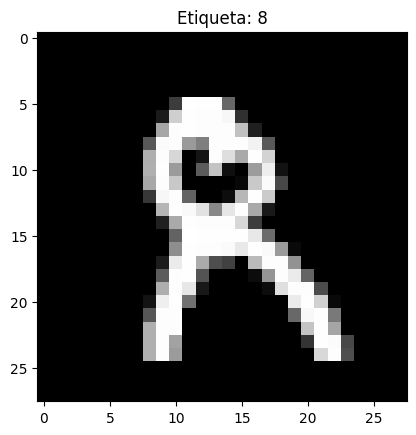

In [ ]:
# Obtener una imagen y su etiqueta
image, label = train_dataset[5]  # Obtener la primera imagen del conjunto de entrenamiento

# Visualizar la imagen
plt.imshow(image.view(28,28), cmap='gray')  # .squeeze() elimina la dimensión de los canales (1,28,28 -> 28,28)
plt.title(f"Etiqueta: {label}")
plt.show()

In [ ]:
class MLP(nn.Module):
    def __init__(self, dropout_rate=0.2):
        super(MLP, self).__init__()
        self.red = nn.Sequential(
            nn.Linear(784, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate),

            nn.Linear(64, 10) # 10 clases (números del 0 al 9)
        )

    def forward(self, x):
        return self.red(x)

In [ ]:
def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    dropout_rate = trial.suggest_float("dropout_rate", 0.1, 0.5)

    model = MLP(dropout_rate).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Entrenamiento rápido de 2 épocas para evaluar qué tan buenos son estos parámetros
    for epoch in range(2):
        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch_X), batch_y)
            loss.backward()
            optimizer.step()

    # Evaluamos en el conjunto DEV
    model.eval()
    correctos, total = 0, 0
    with torch.no_grad():
        for batch_X, batch_y in dev_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            _, predicciones = torch.max(model(batch_X), 1)
            total += batch_y.size(0)
            correctos += (predicciones == batch_y).sum().item()

    return correctos / total # Devolvemos el Accuracy para que Optuna lo intente maximizar

In [ ]:
print("\nIniciando búsqueda con Optuna...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5) # 5 intentos
print(f"\nMejores parámetros encontrados -> {study.best_params}")

[I 2026-03-17 11:59:39,499] A new study created in memory with name: no-name-43e4b6e0-67c6-496f-99f7-b888de96ff9b



Iniciando búsqueda con Optuna...


[I 2026-03-17 12:00:05,995] Trial 0 finished with value: 0.9651 and parameters: {'lr': 0.001454282730571494, 'dropout_rate': 0.229008449249247}. Best is trial 0 with value: 0.9651.
[I 2026-03-17 12:00:31,102] Trial 1 finished with value: 0.9108 and parameters: {'lr': 0.00014696119105914147, 'dropout_rate': 0.4794579533658466}. Best is trial 0 with value: 0.9651.
[I 2026-03-17 12:00:55,583] Trial 2 finished with value: 0.9451 and parameters: {'lr': 0.0009204584535132586, 'dropout_rate': 0.4700324394711811}. Best is trial 0 with value: 0.9651.
[I 2026-03-17 12:01:19,852] Trial 3 finished with value: 0.9357 and parameters: {'lr': 0.000240039344955703, 'dropout_rate': 0.32717390480727926}. Best is trial 0 with value: 0.9651.
[I 2026-03-17 12:01:44,237] Trial 4 finished with value: 0.9211 and parameters: {'lr': 0.00016423476044329248, 'dropout_rate': 0.39314253832822554}. Best is trial 0 with value: 0.9651.



Mejores parámetros encontrados -> {'lr': 0.001454282730571494, 'dropout_rate': 0.229008449249247}


In [ ]:
from torcheval.metrics import MulticlassAccuracy
print("\nEntrenando el modelo final con los mejores parámetros...")
mejor_modelo = MLP(dropout_rate=study.best_params['dropout_rate']).to(device)
mejor_optimizador = optim.Adam(mejor_modelo.parameters(), lr=study.best_params['lr'])
criterion = nn.CrossEntropyLoss()

acc = MulticlassAccuracy(num_classes=10).to(device)
loss_list, acc_list = [], []
# Entrenamos por más épocas (ej. 5) ahora que sabemos cuáles son los mejores parámetros
for epoch in range(5): # (ej. 5)
    mejor_modelo.train()
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        mejor_optimizador.zero_grad()

        outputs = mejor_modelo(batch_X)

        loss = criterion(outputs, batch_y)
        loss.backward()
        mejor_optimizador.step()

        acc.update(outputs, batch_y)

        loss_list.append(loss.item())
        acc_list.append(acc.compute().item())


    acc.reset()


Entrenando el modelo final con los mejores parámetros...


In [ ]:
mejor_modelo.eval()
correctos, total = 0, 0
with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        _, predicciones = torch.max(mejor_modelo(batch_X), 1)
        total += batch_y.size(0)
        correctos += (predicciones == batch_y).sum().item()

accuracy_test = (correctos / total) * 100
print(f"\nRendimiento final en TEST: {accuracy_test:.2f}%")


Rendimiento final en TEST: 97.58%


/tmp/ipykernel_2970/3486502855.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


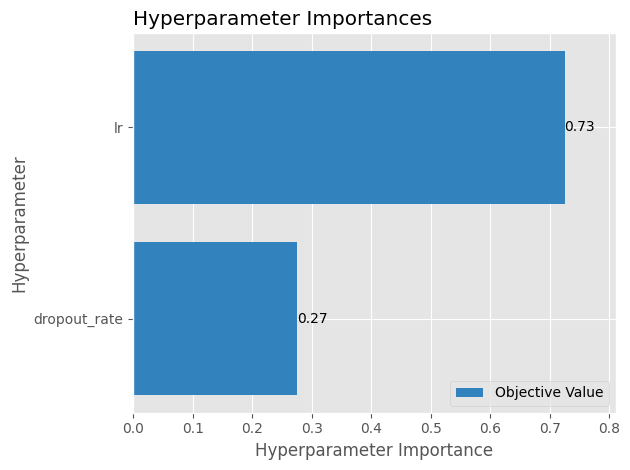

In [ ]:
optuna.visualization.matplotlib.plot_param_importances(study)
plt.tight_layout()
plt.show()

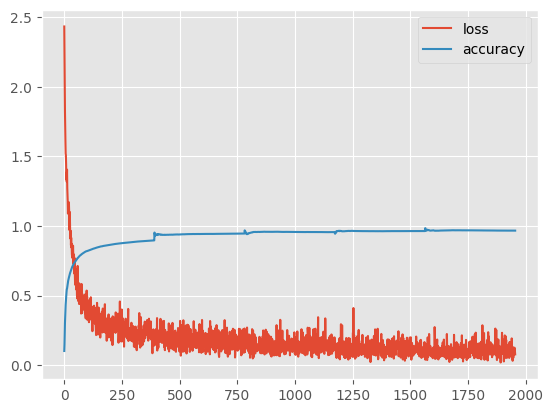

In [ ]:
plt.plot(loss_list)
plt.plot(acc_list)
plt.legend(['loss','accuracy'])
plt.show()